# Nigeria Climate Data Analysis (EDA)

This notebook performs data profiling, cleaning, and exploratory data analysis (EDA) on Nigeria’s climate dataset. The goal is to identify key climate patterns, trends, and relationships relevant to environmental analysis.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)

In [5]:
df = pd.read_csv("../data/nigeria.csv")
df["Country"] = "Nigeria"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria


In [19]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


## Date Processing
The YEAR and DOY columns are combined to create a proper datetime column. A Month column is also extracted for seasonal analysis.

In [20]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10,Nigeria,2026-03-27,3
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49,Nigeria,2026-03-28,3
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22,Nigeria,2026-03-29,3
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73,Nigeria,2026-03-30,3


## Handling Missing Values
Sentinel values (-999) are replaced with NaN to correctly represent missing data.

In [21]:
df.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset. This indicates that the data collection process did not introduce repeated records, and no rows needed to be removed.

In [22]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


## Summary Statistics Interpretation

The dataset contains 4,108 daily observations from 2015 to 2026, providing a detailed overview of Nigeria’s climate.

The average temperature (T2M) is approximately 26.66°C, indicating a consistently hot climate. Temperature variation is relatively small, with a narrow range between minimum and maximum values, suggesting stable daily temperature conditions.

Rainfall (PRECTOTCORR) shows high variability, with a mean of 4.21 mm and extreme values reaching up to 166.1 mm. This indicates the presence of intense rainfall events alongside many low-rainfall days.

Relative humidity (RH2M) is consistently high, averaging around 85%, which reflects moist atmospheric conditions typical of tropical regions.

Wind speeds remain moderate and stable, with an average of about 2.22 m/s.

Overall, the data reflects a hot, humid tropical climate with significant rainfall variability and occasional extreme precipitation events.



In [23]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

### Missing Values Analysis

No missing values were found in the dataset after replacing the sentinel value (-999) with NaN. All columns have 0% missing data, indicating a complete dataset suitable for analysis without additional imputation.

In [24]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M","WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()

outliers

np.int64(297)

## Outlier Detection

Outliers were identified using the Z-score method, where values with an absolute Z-score greater than 3 were considered extreme. A total of 297 outlier values were detected across the selected climate variables.

These outliers likely represent extreme weather events such as intense rainfall or unusual temperature conditions. Since such events are important in climate analysis, the outliers were retained to preserve meaningful environmental variability.

In [25]:
df = df.ffill()

Since no missing values were present in the dataset, no imputation was required. However, forward-fill was applied as a precautionary step to maintain consistency in the workflow.

In [26]:
df.to_csv("../data/nigeria_clean.csv", index=False)

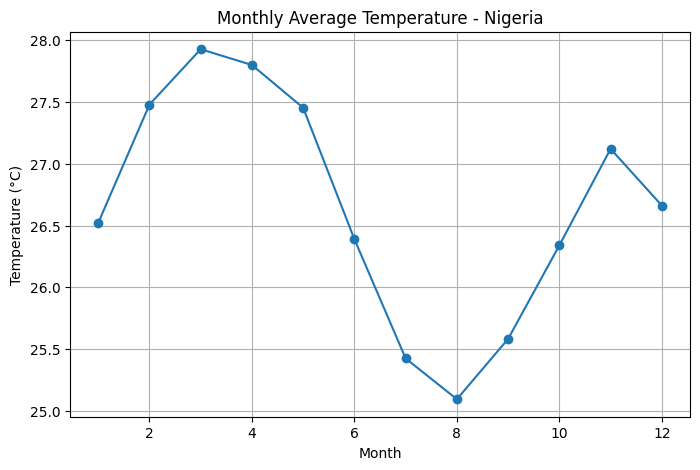

In [27]:
monthly_temp = df.groupby("Month")["T2M"].mean()

monthly_temp.plot(marker='o')
plt.title("Monthly Average Temperature - Nigeria")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

## Temperature Trend Analysis

The temperature pattern in Nigeria shows relatively high values throughout the year, with moderate seasonal variation.

Temperatures increase from January and peak around March, making it the hottest period. After this peak, temperatures gradually decline, reaching the lowest point in August. From September onward, temperatures begin to rise again toward the end of the year.

Overall, the variation in temperature is relatively small, reflecting Nigeria’s consistently warm tropical climate.

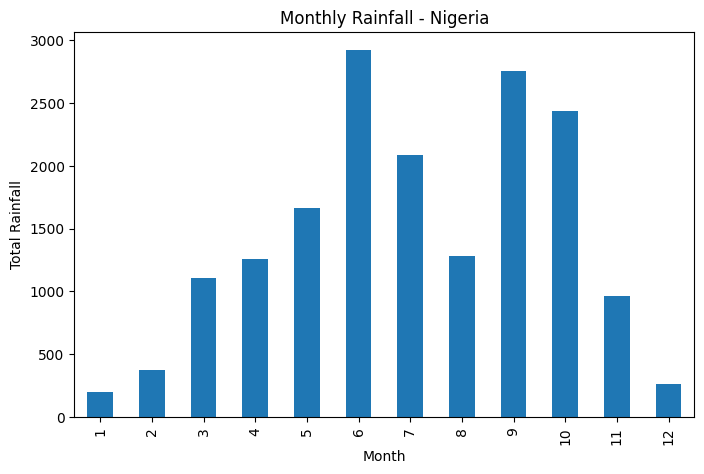

In [28]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall - Nigeria")
plt.xlabel("Month")
plt.ylabel("Total Rainfall")
plt.show()

## Rainfall Pattern Analysis

The rainfall pattern in Nigeria shows a clear seasonal trend with a single extended rainy season.

Rainfall is very low at the beginning of the year (January–February), then gradually increases from March and reaches a major peak in June. After a slight decline in July and August, rainfall rises again with a secondary peak around September and October.

From November onward, rainfall decreases sharply, marking the transition into the dry season.

Overall, this pattern reflects Nigeria’s tropical climate, characterized by a long wet season and a distinct dry period.

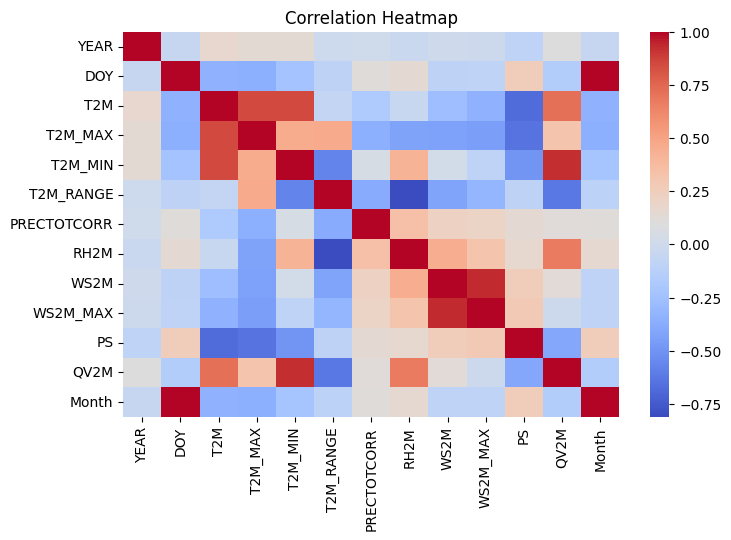

In [29]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis

The correlation heatmap reveals important relationships between climate variables in Nigeria.

Temperature variables (T2M, T2M_MAX, and T2M_MIN) show strong positive correlations with each other, indicating consistent temperature patterns across daily averages, highs, and lows. Humidity (RH2M) has a moderate positive relationship with rainfall (PRECTOTCORR), suggesting that higher moisture levels in the air are associated with increased precipitation.

Wind speed variables (WS2M and WS2M_MAX) are also strongly correlated, reflecting stable wind behavior patterns. Meanwhile, temperature tends to show a slight negative relationship with humidity, meaning higher temperatures are generally associated with lower humidity levels.

Overall, the heatmap highlights clear interdependencies between temperature, humidity, and rainfall, which are key factors influencing Nigeria’s climate dynamics.


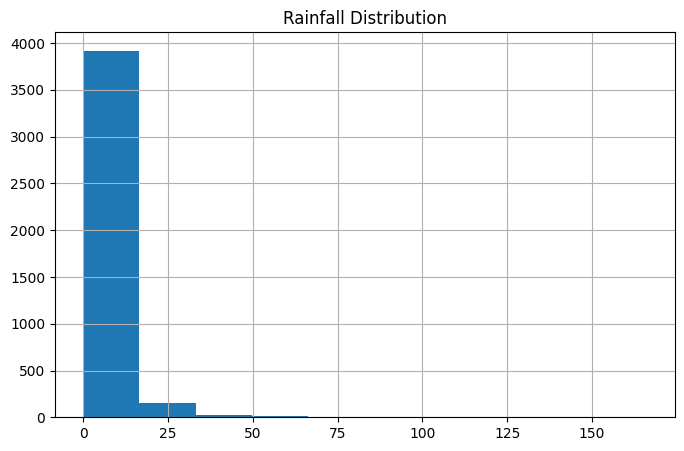

In [31]:
df["PRECTOTCORR"].hist()
plt.title("Rainfall Distribution")
plt.show()

### Rainfall Distribution Analysis

The rainfall distribution is highly right-skewed, with most values concentrated at low levels and a few extreme high rainfall events.

This indicates that rainfall is generally light on most days, but occasionally experiences very heavy rainfall. These extreme events contribute significantly to total annual precipitation and highlight the variability of Nigeria’s climate.

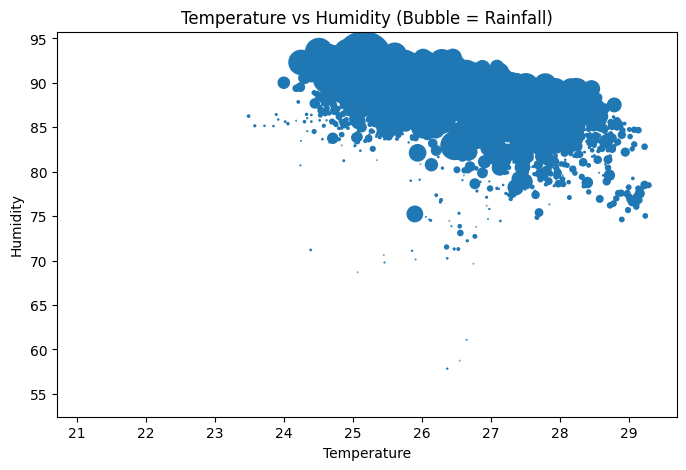

In [32]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10)
plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()

### Temperature vs Humidity Analysis

The scatter plot shows the relationship between temperature and humidity, with bubble size representing rainfall.

There is a clear negative relationship between temperature and humidity—higher temperatures are generally associated with slightly lower humidity levels. Most observations cluster between 24°C and 29°C with high humidity levels (around 80–95%), indicating consistently warm and humid conditions.

Larger bubbles (higher rainfall) tend to occur in areas with higher humidity, suggesting that rainfall is strongly associated with moist atmospheric conditions.

Overall, the pattern reflects a tropical climate, where high humidity dominates and rainfall events are linked to moisture-rich periods.